# SEIRS Model: Waning Immunity and Endemic Equilibrium

## Overview

The **SEIRS (Susceptible-Exposed-Infected-Recovered-Susceptible)** model extends SEIR by adding **waning immunity**, represented by a flow from R back to S. This captures real-world dynamics where recovered individuals gradually lose immunity and can be reinfected.

**Key question**: How does immunity loss structure long-term disease patterns? Does the disease persist at an endemic level or fade away?

**Central teaching goal**: The waning rate ($\rho$) determines whether an epidemic fades (as in SIR/SEIR) or transitions to endemic persistence. This introduces three regimes:
- **No waning** ($\rho = 0$): Epidemic fades to S-R equilibrium (as in SEIR)
- **Fast waning** ($\rho$ large): Disease persists in rapid cycles
- **Slow waning** ($\rho$ small): Disease persists at low endemic level

We keep this notebook free of interventions. The goal is to show how immunity loss reshapes long-term disease dynamics.

## Environment Setup and Reproducibility

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import warnings

from epi_structure import (
    plot_seirs_trajectory,
    show_params,
    simulate_seir_euler,
    simulate_seirs_euler,
)

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')
np.random.seed(42)

# Notebook-friendly aliases used in later cells
simulate_seirs = simulate_seirs_euler
simulate_seir = simulate_seir_euler

## Baseline Parameters

In [2]:
# Baseline simulation parameters (from SEIR)
N = 10_000  # Total population
I0 = 1  # Initial infected
E0 = 0  # Initial exposed (start with none)
R0_value = 2.0  # Basic reproduction number
infectious_period = 6.0  # days
latent_period = 2.0  # days (from notebook 02)
gamma = 1.0 / infectious_period  # recovery rate
sigma = 1.0 / latent_period  # rate of becoming infectious
duration = 500  # days (long-term dynamics for endemic patterns)
dt = 0.1  # timestep

# Compute transmission rate from R0
beta_baseline = R0_value * gamma

# NEW: Waning immunity rate (ρ)
# waning_period is the time for a recovered individual to lose immunity
# ρ = 1 / waning_period
waning_period = 365.0  # days (baseline: 1 year)
rho = 1.0 / waning_period  # waning rate

show_params(
    "SEIRS Baseline Parameters",
    N=N,
    I0=I0,
    R0_baseline=R0_value,
    infectious_period=infectious_period,
    latent_period=latent_period,
    beta=beta_baseline,
    sigma=sigma,
    rho=rho,
    waning_period_days=waning_period,
    duration_days=duration,
)


SEIRS Baseline Parameters:
  N                        = 10000
  I0                       = 1
  R0_baseline              = 2.000000
  infectious_period        = 6.000000
  latent_period            = 2.000000
  beta                     = 0.333333
  sigma                    = 0.500000
  rho                      = 0.002740
  waning_period_days       = 365.000000
  duration_days            = 500


## SEIRS Simulation Function

In [3]:
print("simulate_seirs() loaded from epi_structure.notebook_helpers")

simulate_seirs() loaded from epi_structure.notebook_helpers


## Baseline SEIRS Run (1-Year Waning)

In [4]:
# Run SEIRS with 1-year waning period
times, S, E, I, R, incidence = simulate_seirs(
    N=N, I0=I0, E0=E0, R0_value=R0_value,
    gamma=gamma, sigma=sigma, rho=rho,
    duration=duration, dt=dt
)

# Check population conservation
total_pop = S + E + I + R
max_dev = np.abs(total_pop - N).max()
print(f"Population conservation check: Max deviation: {max_dev:.1f} ({100*max_dev/N:.4f}%)")

# Summary statistics
peak_I = I.max()
t_peak = times[I.argmax()]
final_attack_rate = R[-1]  # final R

print(f"\nBaseline SEIRS (waning_period=1 year):")
print(f"  Peak infected: {peak_I:.1f} ({100*peak_I/N:.2f}%)")
print(f"  Time to peak: {t_peak:.1f} days")
print(f"  Final recovered: {final_attack_rate:.1f} ({100*final_attack_rate/N:.2f}%)")
print(f"  Final susceptible: {S[-1]:.1f} ({100*S[-1]/N:.2f}%)")

Population conservation check: Max deviation: 0.0 (0.0000%)

Baseline SEIRS (waning_period=1 year):
  Peak infected: 1171.5 (11.72%)
  Time to peak: 83.9 days
  Final recovered: 3728.2 (37.28%)
  Final susceptible: 5980.4 (59.80%)


## Visualize Baseline SEIRS Trajectory

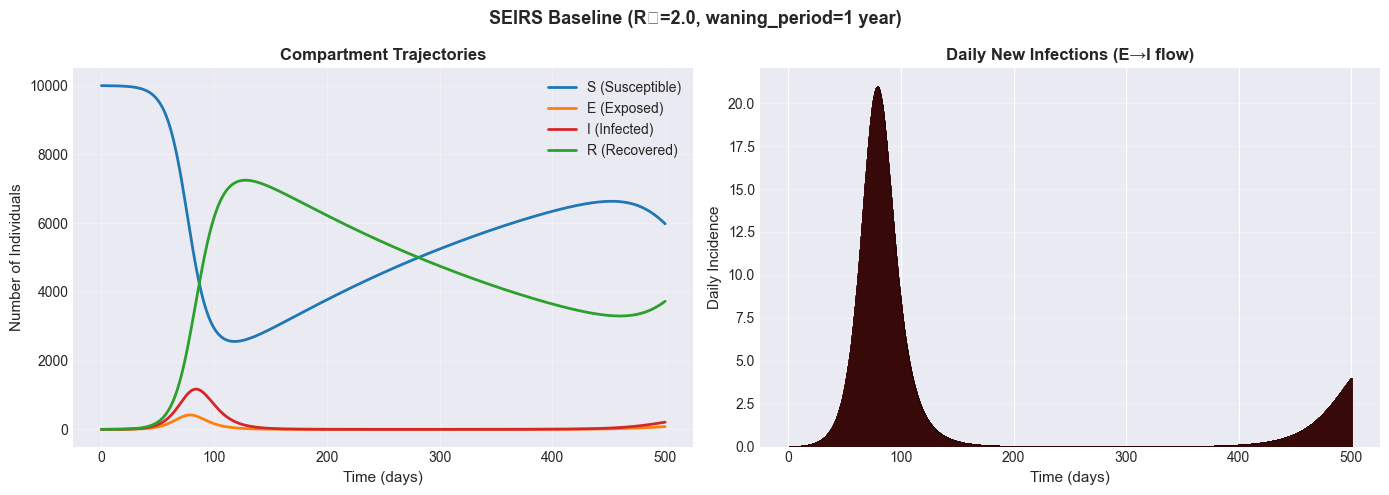

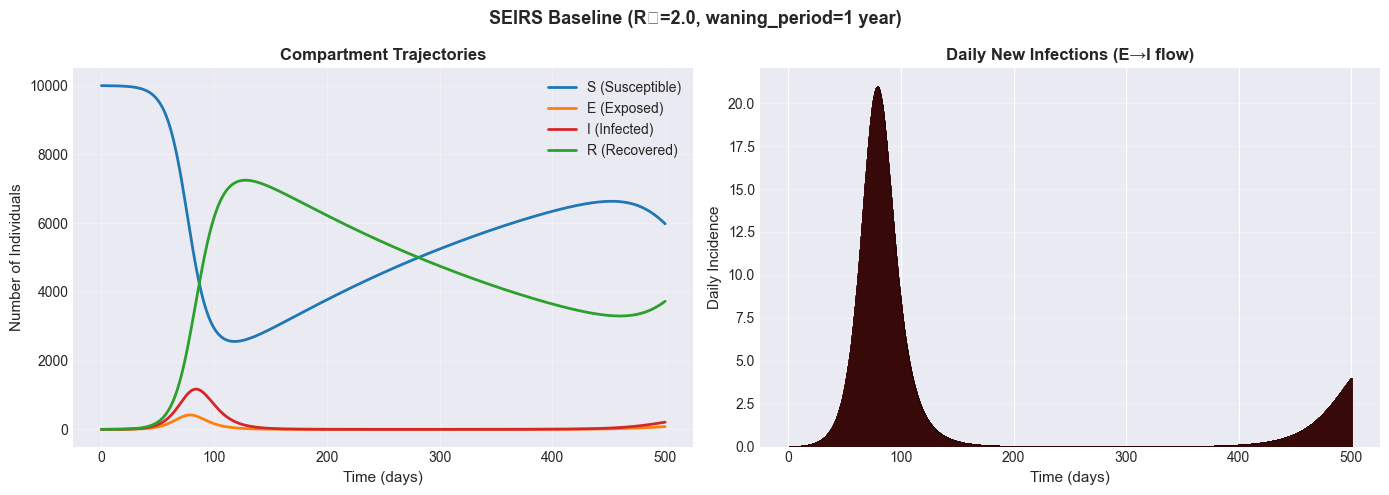

In [5]:
plot_seirs_trajectory(
    times, S, E, I, R, incidence,
    title="SEIRS Baseline (R₀=2.0, waning_period=1 year)"
)

## Compare SEIR (No Waning) vs SEIRS (1-Year Waning)

In [6]:
# Run SEIR (ρ=0, no waning) for comparison
times_seir, S_seir, E_seir, I_seir, R_seir, inc_seir = simulate_seir(
    N=N,
    I0=I0,
    E0=E0,
    R0_value=R0_value,
    gamma=gamma,
    sigma=sigma,
    duration=duration,
    dt=dt,
)

print(f"SEIR (no waning) final state:")
print(f"  Peak infected: {I_seir.max():.1f}")
print(f"  Time to peak: {times_seir[I_seir.argmax()]:.1f} days")
print(f"  Final recovered: {R_seir[-1]:.1f}")
print(f"  Final susceptible: {S_seir[-1]:.1f}")

SEIR (no waning) final state:
  Peak infected: 1148.7
  Time to peak: 83.6 days
  Final recovered: 7975.4
  Final susceptible: 2024.6


## Overlay: SEIR vs SEIRS

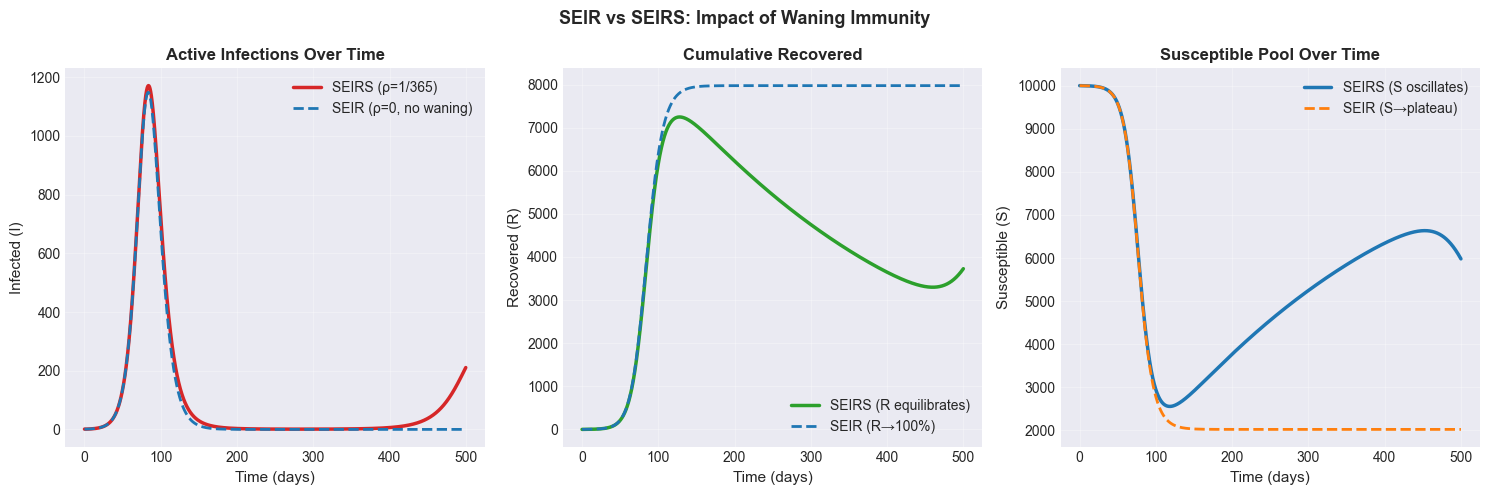


Key Observation:
  SEIR: Disease fades after ~250 days (everyone recovered or immune)
  SEIRS: Disease persists in damped oscillations as S→R→S waning cycle continues


In [7]:
fig = plt.figure(figsize=(15, 5))
gs = GridSpec(1, 3, figure=fig)

# Panel 1: I(t) comparison
ax0 = fig.add_subplot(gs[0, 0])
ax0.plot(times, I, label="SEIRS (ρ=1/365)", linewidth=2.5, color="#d62728")
ax0.plot(times_seir, I_seir, label="SEIR (ρ=0, no waning)", linewidth=2, linestyle="--", color="#1f77b4")
ax0.set_xlabel("Time (days)", fontsize=11)
ax0.set_ylabel("Infected (I)", fontsize=11)
ax0.set_title("Active Infections Over Time", fontsize=12, fontweight='bold')
ax0.legend(fontsize=10)
ax0.grid(True, alpha=0.3)

# Panel 2: R(t) comparison
ax1 = fig.add_subplot(gs[0, 1])
ax1.plot(times, R, label="SEIRS (R equilibrates)", linewidth=2.5, color="#2ca02c")
ax1.plot(times_seir, R_seir, label="SEIR (R→100%)", linewidth=2, linestyle="--", color="#1f77b4")
ax1.set_xlabel("Time (days)", fontsize=11)
ax1.set_ylabel("Recovered (R)", fontsize=11)
ax1.set_title("Cumulative Recovered", fontsize=12, fontweight='bold')
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)

# Panel 3: S(t) comparison
ax2 = fig.add_subplot(gs[0, 2])
ax2.plot(times, S, label="SEIRS (S oscillates)", linewidth=2.5, color="#1f77b4")
ax2.plot(times_seir, S_seir, label="SEIR (S→plateau)", linewidth=2, linestyle="--", color="#ff7f0e")
ax2.set_xlabel("Time (days)", fontsize=11)
ax2.set_ylabel("Susceptible (S)", fontsize=11)
ax2.set_title("Susceptible Pool Over Time", fontsize=12, fontweight='bold')
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)

fig.suptitle("SEIR vs SEIRS: Impact of Waning Immunity", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nKey Observation:")
print("  SEIR: Disease fades after ~250 days (everyone recovered or immune)")
print("  SEIRS: Disease persists in damped oscillations as S→R→S waning cycle continues")

## Waning Period Sensitivity Sweep

In [8]:
# Test multiple waning periods
waning_periods = [365, 730, 1825, 3650]  # 1, 2, 5, 10 years
waning_labels = ["1 year", "2 years", "5 years", "10 years"]

sweep_results = []

for waning_days, label in zip(waning_periods, waning_labels):
    rho_sweep = 1.0 / waning_days
    
    times_sweep, S_sweep, E_sweep, I_sweep, R_sweep, inc_sweep = simulate_seirs(
        N=N, I0=I0, E0=E0, R0_value=R0_value,
        gamma=gamma, sigma=sigma, rho=rho_sweep,
        duration=duration, dt=dt
    )
    
    # Metrics: evaluate only after epidemic established (skip first 100 days)
    t_start = 100
    idx_start = int(t_start / dt)
    
    I_endemic = I_sweep[idx_start:]
    S_endemic = S_sweep[idx_start:]
    R_endemic = R_sweep[idx_start:]
    
    mean_I = I_endemic.mean()
    peak_I_endemic = I_endemic.max()
    mean_S = S_endemic.mean()
    
    sweep_results.append({
        'waning_period': waning_days,
        'waning_label': label,
        'mean_I': mean_I,
        'peak_I': peak_I_endemic,
        'mean_S': mean_S,
    })

df_waning = pd.DataFrame(sweep_results)
print("\nWaning Period Sensitivity (evaluated from day 100 onward):")
print(df_waning.to_string(index=False))


Waning Period Sensitivity (evaluated from day 100 onward):
 waning_period waning_label    mean_I     peak_I      mean_S
           365       1 year 45.182598 722.706355 4967.275045
           730      2 years 26.123730 699.896870 3826.600214
          1825      5 years 24.576763 686.133447 2838.262582
          3650     10 years 24.095174 681.533294 2457.212092


## Visualize Waning Period Effects

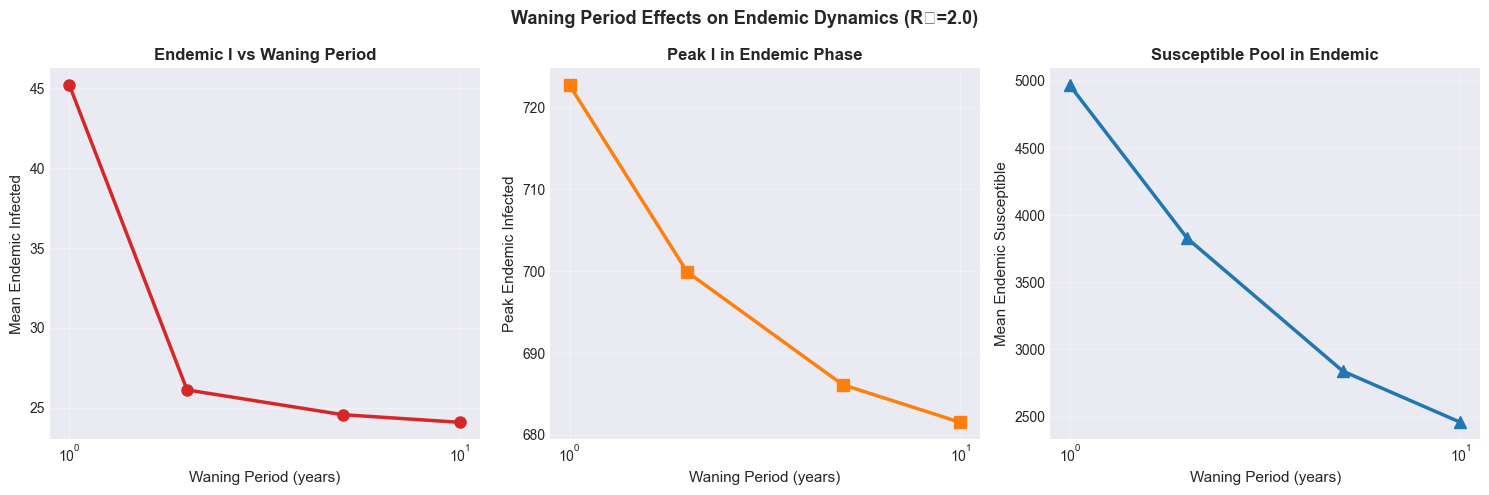


Key Observations:
  - Faster waning (shorter period): Higher endemic I and faster oscillations
  - Slower waning (longer period): Lower endemic I, approach to SEIR-like fade
  - Susceptible pool: Inversely related to waning speed


In [9]:
fig = plt.figure(figsize=(15, 5))
gs = GridSpec(1, 3, figure=fig)

# Panel 1: Mean endemic I vs waning period
ax0 = fig.add_subplot(gs[0, 0])
ax0.plot(df_waning['waning_period']/365, df_waning['mean_I'], marker='o', linewidth=2.5, markersize=8, color="#d62728")
ax0.set_xlabel("Waning Period (years)", fontsize=11)
ax0.set_ylabel("Mean Endemic Infected", fontsize=11)
ax0.set_title("Endemic I vs Waning Period", fontsize=12, fontweight='bold')
ax0.grid(True, alpha=0.3)
ax0.set_xscale('log')

# Panel 2: Peak I in endemic phase
ax1 = fig.add_subplot(gs[0, 1])
ax1.plot(df_waning['waning_period']/365, df_waning['peak_I'], marker='s', linewidth=2.5, markersize=8, color="#ff7f0e")
ax1.set_xlabel("Waning Period (years)", fontsize=11)
ax1.set_ylabel("Peak Endemic Infected", fontsize=11)
ax1.set_title("Peak I in Endemic Phase", fontsize=12, fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.set_xscale('log')

# Panel 3: Mean susceptible in endemic
ax2 = fig.add_subplot(gs[0, 2])
ax2.plot(df_waning['waning_period']/365, df_waning['mean_S'], marker='^', linewidth=2.5, markersize=8, color="#1f77b4")
ax2.set_xlabel("Waning Period (years)", fontsize=11)
ax2.set_ylabel("Mean Endemic Susceptible", fontsize=11)
ax2.set_title("Susceptible Pool in Endemic", fontsize=12, fontweight='bold')
ax2.grid(True, alpha=0.3)
ax2.set_xscale('log')

fig.suptitle("Waning Period Effects on Endemic Dynamics (R₀=2.0)", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nKey Observations:")
print("  - Faster waning (shorter period): Higher endemic I and faster oscillations")
print("  - Slower waning (longer period): Lower endemic I, approach to SEIR-like fade")
print("  - Susceptible pool: Inversely related to waning speed")

## Side-by-Side Trajectories: Different Waning Rates

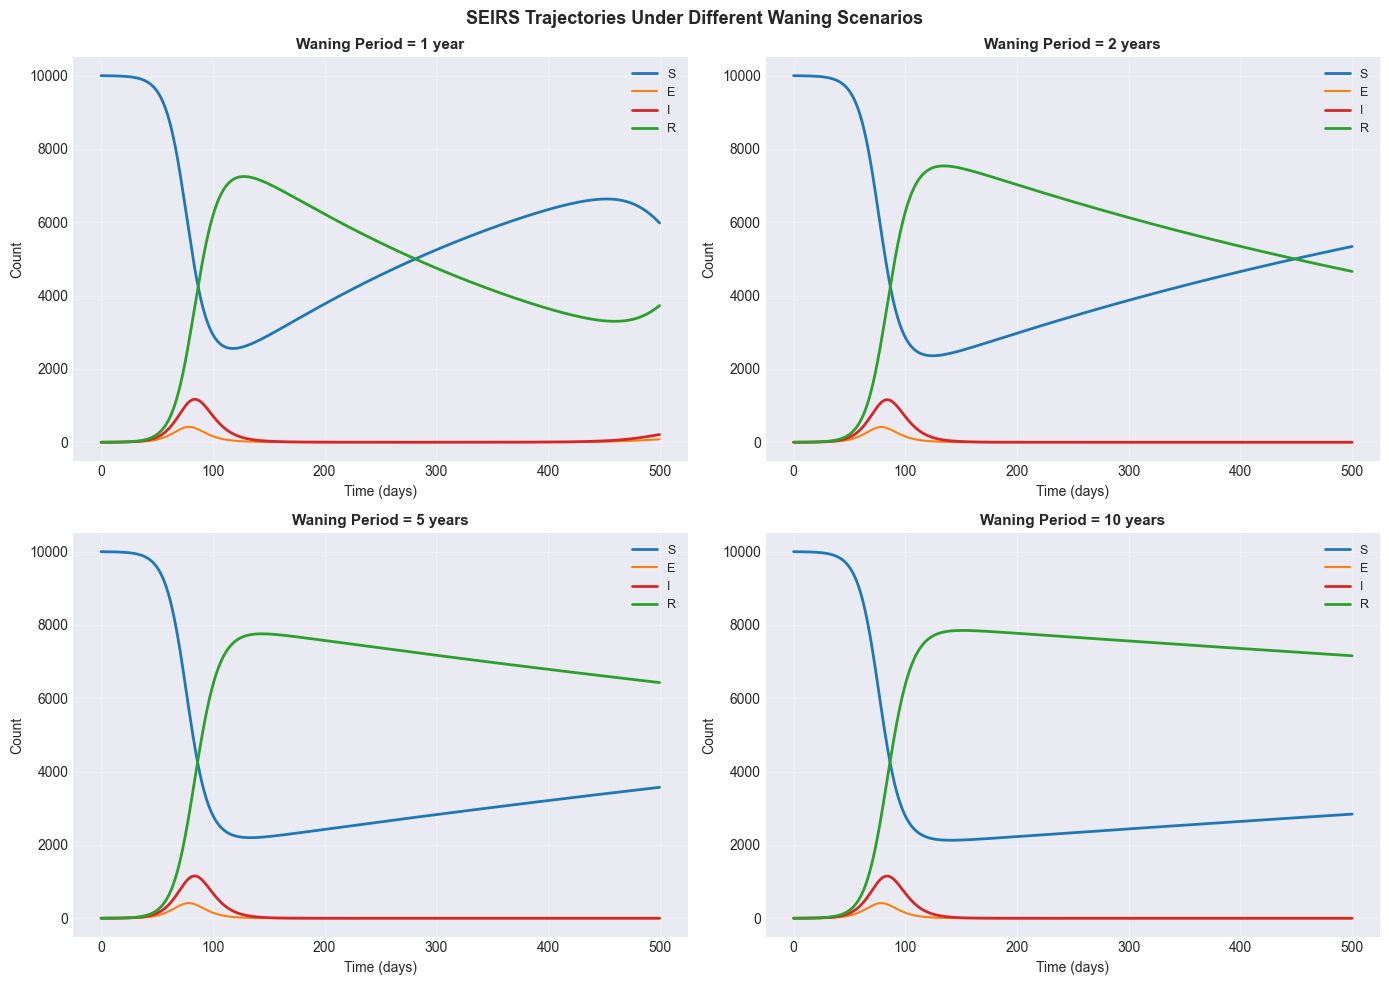

In [10]:
# Run all four scenarios and plot
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

waning_periods_full = [365, 730, 1825, 3650]
waning_labels_full = ["1 year", "2 years", "5 years", "10 years"]

for idx, (waning_days, label) in enumerate(zip(waning_periods_full, waning_labels_full)):
    ax = axes[idx // 2, idx % 2]
    
    rho_sweep = 1.0 / waning_days
    times_sweep, S_sweep, E_sweep, I_sweep, R_sweep, inc_sweep = simulate_seirs(
        N=N, I0=I0, E0=E0, R0_value=R0_value,
        gamma=gamma, sigma=sigma, rho=rho_sweep,
        duration=duration, dt=dt
    )
    
    ax.plot(times_sweep, S_sweep, label="S", linewidth=2, color="#1f77b4")
    ax.plot(times_sweep, E_sweep, label="E", linewidth=1.5, color="#ff7f0e")
    ax.plot(times_sweep, I_sweep, label="I", linewidth=2, color="#d62728")
    ax.plot(times_sweep, R_sweep, label="R", linewidth=2, color="#2ca02c")
    ax.set_xlabel("Time (days)", fontsize=10)
    ax.set_ylabel("Count", fontsize=10)
    ax.set_title(f"Waning Period = {label}", fontsize=11, fontweight='bold')
    ax.legend(fontsize=9, loc='best')
    ax.grid(True, alpha=0.3)

fig.suptitle("SEIRS Trajectories Under Different Waning Scenarios", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## Interpretation: Waning and Endemic Equilibrium

**Mechanism**: The waning rate ρ determines whether the disease reaches a *transient epidemic* (SEIR-like fade) or transitions to *endemic persistence*. This is controlled by the interplay between recovery (R→) and waning (R→S).

**Three Regimes**:

1. **No waning (ρ = 0)**: Disease fades after peak; all susceptibles either recover or get infected and then remain immune forever → final state is S + R = N (epidemic dies out)
   
2. **Fast waning (short period)**: Recovered individuals quickly become susceptible again → disease cycles rapidly at higher endemic levels; resembles damped oscillations but persists indefinitely
   
3. **Slow waning (long period)**: Recovered individuals slowly become susceptible → disease persists but at lower endemic levels; appears almost like SEIR fade but with tiny recurrent waves

**Endemic Equilibrium**: When ρ > 0, the disease does NOT die out. Instead, the system approaches a *dynamic equilibrium* where births and deaths (not included here, but in full models) balance with waning and transmission.

## Summary and Key Takeaways

### What We Learned

1. **SEIR vs SEIRS**: Without waning (ρ = 0), the disease fades after a single epidemic wave. With waning (ρ > 0), the disease persists indefinitely in endemic cycles.

2. **Waning Rate Governs Persistence**: The timescale for immunity loss directly controls:
   - How long individuals remain immune
   - How frequently epidemic waves recur
   - The steady-state endemic level

3. **No "Herd Immunity" Endpoint**: Classic SIR/SEIR models reach herd immunity and fade. SEIRS models with waning never reach herd immunity because recovered individuals become susceptible again.

4. **Disease Persistence is Multifactorial**: 
   - R₀ determines the intensity (from notebook 01)
   - Latent period affects timing (from notebook 02)
   - Waning rate determines persistence (this notebook)

### Biological Examples

- **Measles**: Very long-term immunity (effectively no waning in pre-vaccine era) → periodic epidemics every few years (driven by birth rate, not waning)
- **Whooping cough**: Moderate waning (immunity lasts ~5-10 years) → gradual loss of protection, recurrent waves
- **COVID-19**: Variable waning (weeks to months for original Omicron, antibody-based) → rapid reinfection waves, requires vaccination boosters
- **Seasonal influenza**: Very rapid waning (mutation) and seasonality → annual epidemics

### Next Steps

In **Notebook 04**, we extend to **multi-population models** by adding structure (general vs cluster populations) and contact matrices. This introduces questions about how disease spreads *between* populations with different transmission rates.

## Appendix: SEIRS ODE Equations

### Full SEIRS System

The **SEIRS model** has four compartments and two flows in/out:

$$\frac{dS}{dt} = -\beta \frac{S I}{N} + \rho R$$

$$\frac{dE}{dt} = \beta \frac{S I}{N} - \sigma E$$

$$\frac{dI}{dt} = \sigma E - \gamma I$$

$$\frac{dR}{dt} = \gamma I - \rho R$$

With constraint: $S + E + I + R = N$

### Parameters

| Symbol | Meaning | Example |
|--------|---------|----------|
| $N$ | Total population | 10,000 |
| $\beta$ | Transmission rate (per contact, per day) | 0.334 day$^{-1}$ |
| $\sigma$ | Rate of becoming infectious | $1/2$ day$^{-1}$ (2-day latent) |
| $\gamma$ | Recovery rate | $1/6$ day$^{-1}$ (6-day infectious) |
| $\rho$ | Waning immunity rate | $1/365$ day$^{-1}$ (1-year immunity) |
| $R_0$ | Basic reproduction number | $\beta / \gamma$ |

### Biological Interpretation

- **$-\beta S I / N$**: Force of infection; susceptibles exposed at rate proportional to infected fraction
- **$+\rho R$**: Waning; recovered individuals lose immunity and return to susceptible pool
- **$\sigma E$**: Progression; exposed individuals progress to infectious at fixed rate
- **$\gamma I$**: Recovery; infectious individuals recover at fixed rate

### Endemic Equilibrium (when no births/deaths)

When $\rho > 0$ (waning immunity exists), the disease does not die out but settles into damped oscillations. In a real population with births and deaths included, a true endemic equilibrium (constant endemic level) emerges.

Without waning ($\rho = 0$), epidemic eventually fades and final state has:
$$S^* + R^* = N, \quad I^* = E^* = 0$$

With waning ($\rho > 0$), disease persists indefinitely in cycles.